In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:

print("Downloading data from Yahoo Finance...")


tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'


raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

close_prices = raw_data['Close']

print(f"\nData shape: {raw_data.shape}")
print(f"Date range: {close_prices.index[0].date()} to {close_prices.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(close_prices.head())
print(f"\nLast 5 rows:")
print(close_prices.tail())

[*********************100%***********************]  3 of 3 completed


Data shape: (2888, 15)
Date range: 2015-01-02 to 2026-06-29

First 5 rows:
Ticker            BND         SPY       TSLA
Date                                        
2015-01-02  59.405415  169.687866  14.620667
2015-01-05  59.577930  166.623352  14.006000
2015-01-06  59.750378  165.053925  14.085333
2015-01-07  59.786312  167.110657  14.063333
2015-01-08  59.692917  170.076035  14.041333

Last 5 rows:
Ticker            BND         SPY        TSLA
Date                                         
2026-06-23  72.976631  733.580017  381.609985
2026-06-24  73.305534  733.239990  375.529999
2026-06-25  73.355370  734.299988  375.119995
2026-06-26  73.425133  728.989990  379.709991
2026-06-29  73.465004  741.000000  411.839996


In [3]:

print("=== DATA CLEANING ===\n")

print("Missing values per asset:")
print(close_prices.isnull().sum())

close_prices = close_prices.ffill().bfill()

print(f"\nAfter cleaning - Missing values:")
print(close_prices.isnull().sum())


print("\n=== BASIC STATISTICS ===")
print(close_prices.describe().round(2))

print("\n=== DATA TYPES ===")
print(close_prices.dtypes)


import os
os.makedirs('../data/processed', exist_ok=True)
close_prices.to_csv('../data/processed/close_prices.csv')
print("\nData saved to data/processed/close_prices.csv")

=== DATA CLEANING ===

Missing values per asset:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

After cleaning - Missing values:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

=== BASIC STATISTICS ===
Ticker      BND      SPY     TSLA
count   2888.00  2888.00  2888.00
mean      66.50   351.51   148.77
std        4.71   155.44   138.90
min       58.73   154.16     9.58
25%       62.48   223.55    18.39
50%       65.73   312.82   133.44
75%       70.69   432.81   251.93
max       74.83   757.62   489.88

=== DATA TYPES ===
Ticker
BND     float64
SPY     float64
TSLA    float64
dtype: object

Data saved to data/processed/close_prices.csv


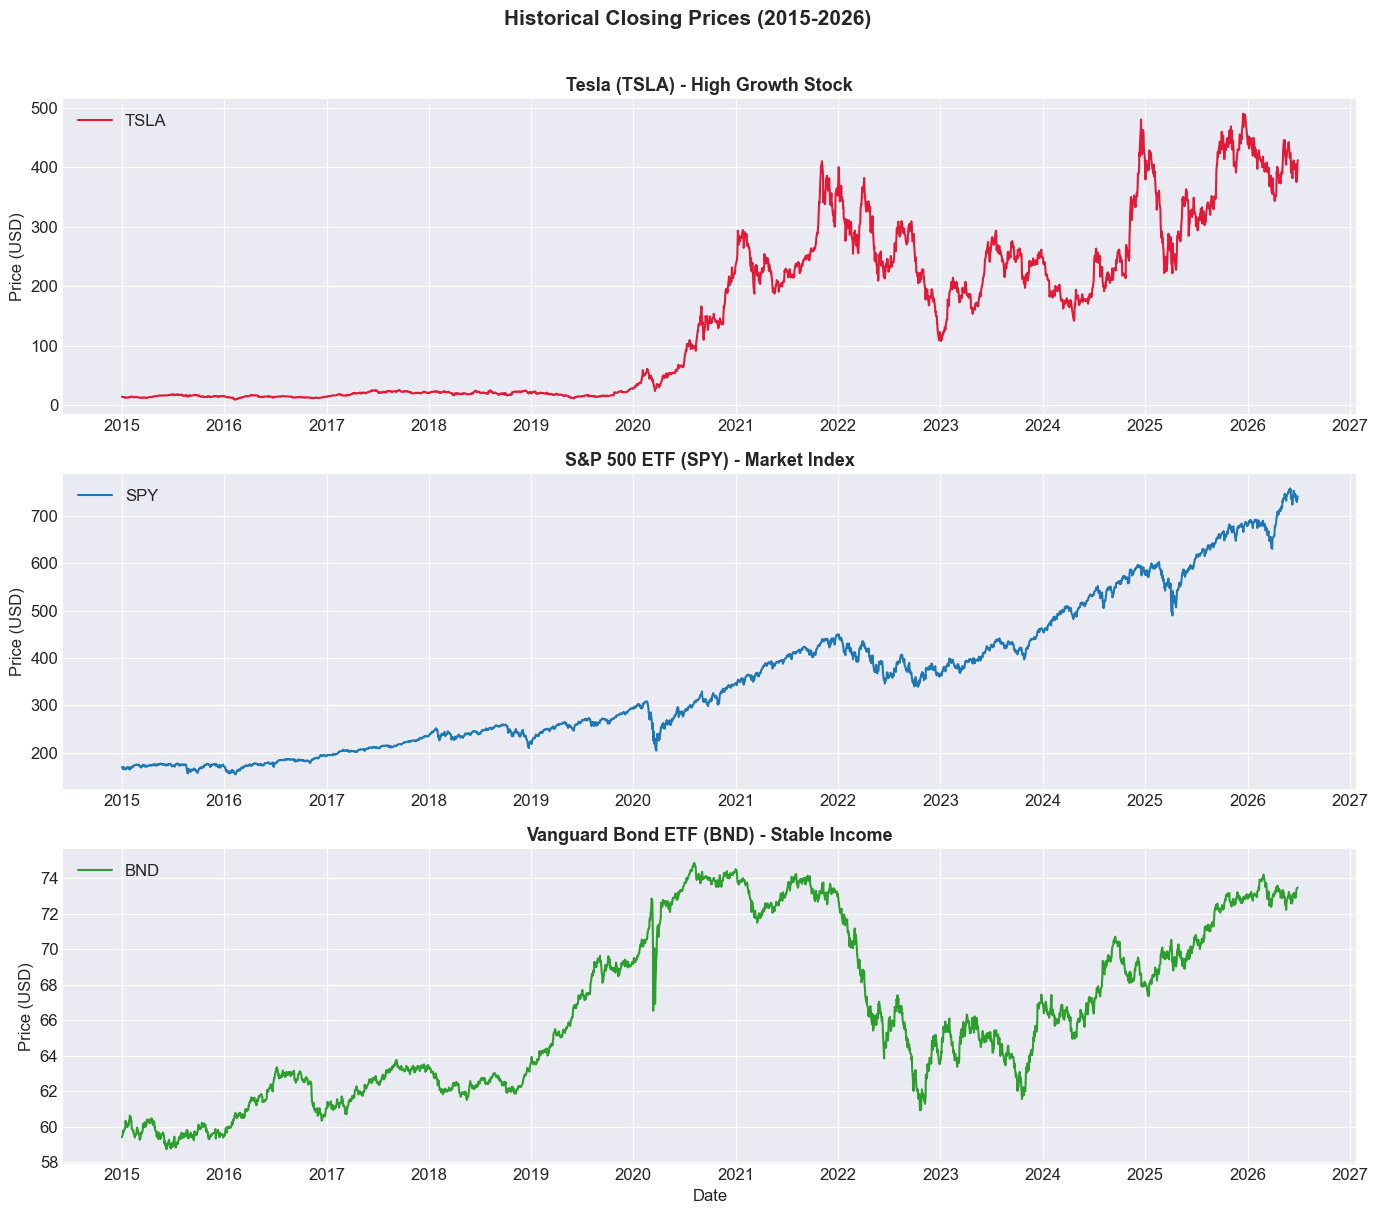

Chart saved!


In [4]:

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = {'TSLA': '#E31937', 'SPY': '#1f77b4', 'BND': '#2ca02c'}
titles = {
    'TSLA': 'Tesla (TSLA) - High Growth Stock',
    'SPY': 'S&P 500 ETF (SPY) - Market Index',
    'BND': 'Vanguard Bond ETF (BND) - Stable Income'
}

for idx, ticker in enumerate(['TSLA', 'SPY', 'BND']):
    axes[idx].plot(close_prices.index, close_prices[ticker],
                   color=colors[ticker], linewidth=1.5, label=ticker)
    axes[idx].set_title(titles[ticker], fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend(loc='upper left')
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[idx].xaxis.set_major_locator(mdates.YearLocator())

axes[2].set_xlabel('Date')
plt.suptitle('Historical Closing Prices (2015-2026)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/closing_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== DAILY RETURNS ANALYSIS ===

Daily Returns Statistics:
Ticker        BND        SPY       TSLA
count   2887.0000  2887.0000  2887.0000
mean       0.0001     0.0006     0.0018
std        0.0033     0.0111     0.0360
min       -0.0544    -0.1094    -0.2106
25%       -0.0015    -0.0037    -0.0166
50%        0.0001     0.0007     0.0012
75%        0.0018     0.0059     0.0195
max        0.0422     0.1050     0.2269


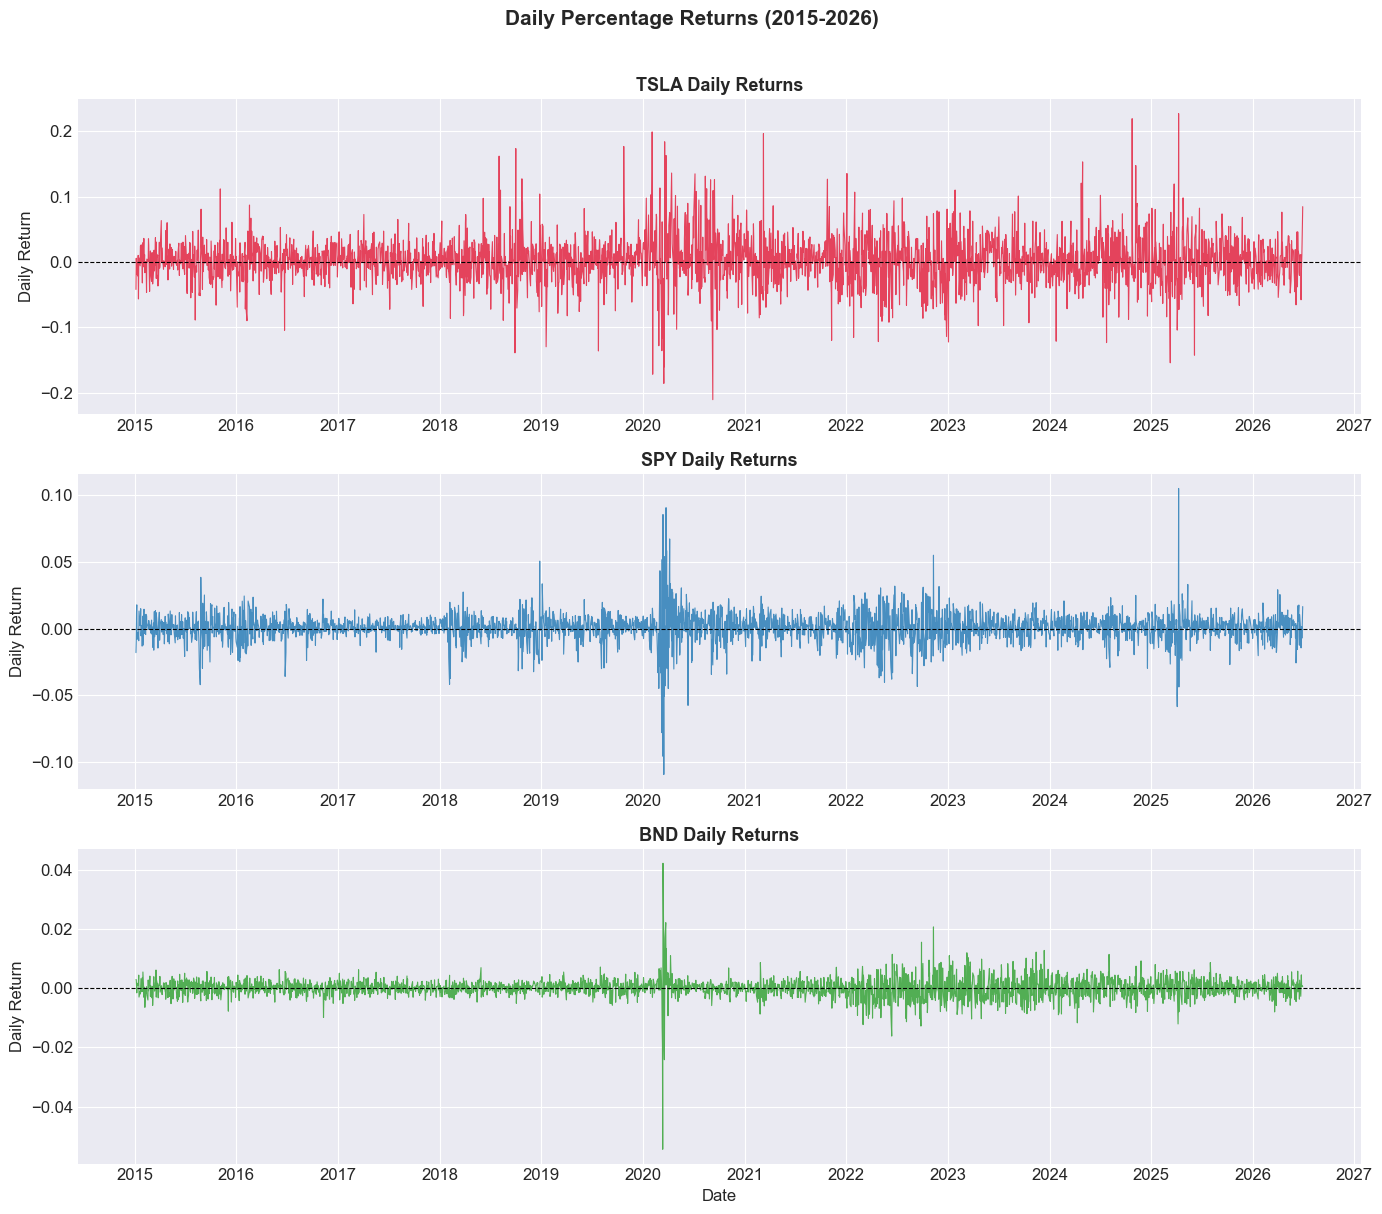

Chart saved!


In [5]:

print("=== DAILY RETURNS ANALYSIS ===\n")

daily_returns = close_prices.pct_change().dropna()

print("Daily Returns Statistics:")
print(daily_returns.describe().round(4))


fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = {'TSLA': '#E31937', 'SPY': '#1f77b4', 'BND': '#2ca02c'}

for idx, ticker in enumerate(['TSLA', 'SPY', 'BND']):
    axes[idx].plot(daily_returns.index, daily_returns[ticker],
                   color=colors[ticker], linewidth=0.8, alpha=0.8)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[idx].set_title(f'{ticker} Daily Returns', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Daily Return')
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[idx].xaxis.set_major_locator(mdates.YearLocator())

axes[2].set_xlabel('Date')
plt.suptitle('Daily Percentage Returns (2015-2026)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== OUTLIER DETECTION ===

TSLA Outliers (beyond 3 std devs): 46 days
  Largest gain:  22.69% on 2025-04-09
  Largest loss:  -21.06% on 2020-09-08

SPY Outliers (beyond 3 std devs): 39 days
  Largest gain:  10.50% on 2025-04-09
  Largest loss:  -10.94% on 2020-03-16

BND Outliers (beyond 3 std devs): 33 days
  Largest gain:  4.22% on 2020-03-13
  Largest loss:  -5.44% on 2020-03-12



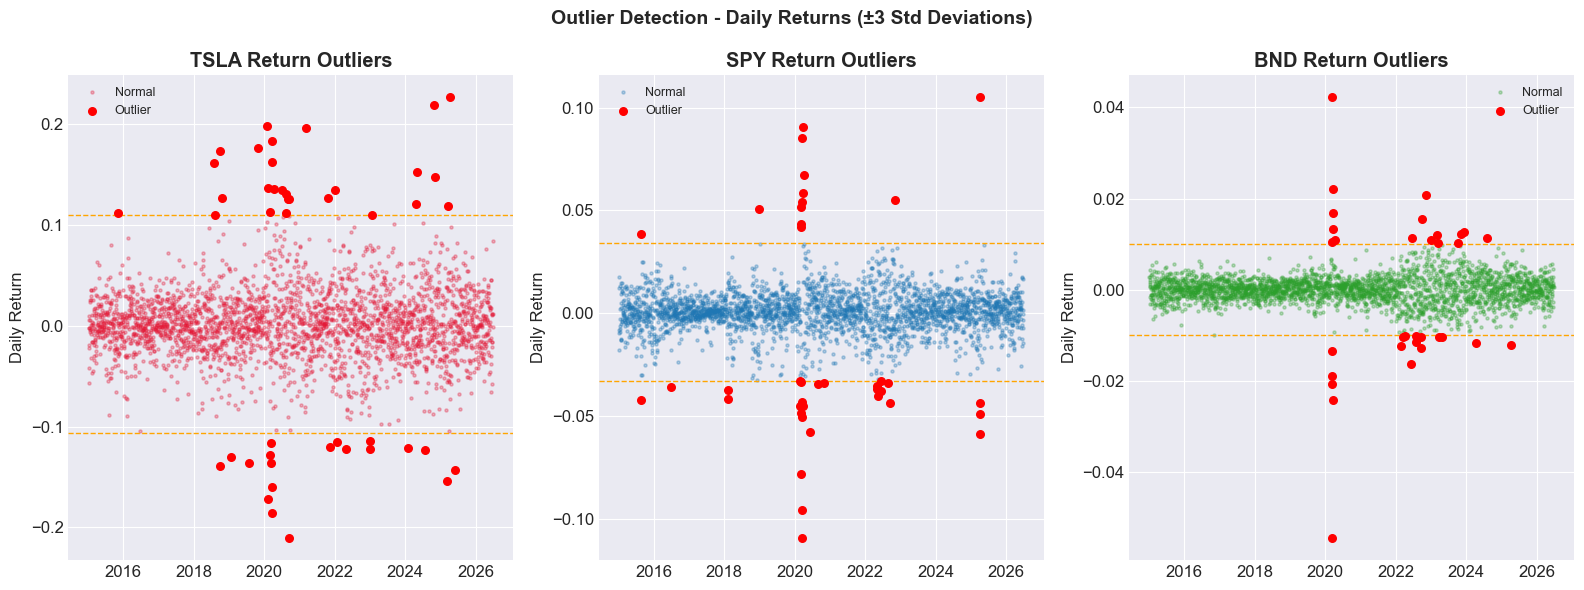

Chart saved!


In [ ]:

print("=== OUTLIER DETECTION ===\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = {'TSLA': '#E31937', 'SPY': '#1f77b4', 'BND': '#2ca02c'}

for idx, ticker in enumerate(['TSLA', 'SPY', 'BND']):
    returns = daily_returns[ticker]
    mean = returns.mean()
    std = returns.std()

    # Define outliers as beyond 3 standard deviations
    outliers = returns[np.abs(returns - mean) > 3 * std]

    print(f"{ticker} Outliers (beyond 3 std devs): {len(outliers)} days")
    print(f"  Largest gain:  {returns.max():.2%} on {returns.idxmax().date()}")
    print(f"  Largest loss:  {returns.min():.2%} on {returns.idxmin().date()}")
    print()

    # Plot
    axes[idx].scatter(returns.index, returns,
                      color=colors[ticker], alpha=0.3, s=5, label='Normal')
    axes[idx].scatter(outliers.index, outliers,
                      color='red', s=30, zorder=5, label='Outlier')
    axes[idx].axhline(y=mean + 3*std, color='orange', linestyle='--', linewidth=1)
    axes[idx].axhline(y=mean - 3*std, color='orange', linestyle='--', linewidth=1)
    axes[idx].set_title(f'{ticker} Return Outliers', fontweight='bold')
    axes[idx].set_ylabel('Daily Return')
    axes[idx].legend(fontsize=9)
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[idx].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Outlier Detection - Daily Returns (±3 Std Deviations)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:

print("=== STATIONARITY TEST (Augmented Dickey-Fuller) ===\n")

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"--- {name} ---")
    print(f"ADF Statistic:  {result[0]:.4f}")
    print(f"p-value:        {result[1]:.4f}")
    print(f"Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")
    if result[1] < 0.05:
        print(f"Result: STATIONARY (p < 0.05) ✓")
    else:
        print(f"Result: NON-STATIONARY (p >= 0.05) ✗")
    print()

print("== CLOSING PRICES ==")
for ticker in ['TSLA', 'SPY', 'BND']:
    adf_test(close_prices[ticker], f"{ticker} Close Price")

print("== DAILY RETURNS ==")
for ticker in ['TSLA', 'SPY', 'BND']:
    adf_test(daily_returns[ticker], f"{ticker} Daily Returns")

=== STATIONARITY TEST (Augmented Dickey-Fuller) ===

== CLOSING PRICES ==
--- TSLA Close Price ---
ADF Statistic:  -1.0696
p-value:        0.7270
Critical Values:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673
Result: NON-STATIONARY (p >= 0.05) ✗

--- SPY Close Price ---
ADF Statistic:  1.3089
p-value:        0.9967
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Result: NON-STATIONARY (p >= 0.05) ✗

--- BND Close Price ---
ADF Statistic:  -1.0827
p-value:        0.7219
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Result: NON-STATIONARY (p >= 0.05) ✗

== DAILY RETURNS ==
--- TSLA Daily Returns ---
ADF Statistic:  -53.9719
p-value:        0.0000
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Result: STATIONARY (p < 0.05) ✓

--- SPY Daily Returns ---
ADF Statistic:  -17.5722
p-value:        0.0000
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Result: STATIONARY (p < 0.05) ✓

--- BND Daily Returns ---
ADF Statistic:  -15.216

=== RISK METRICS ===

--- TSLA ---
Annualized Return:    45.42%
Annualized Volatility:57.18%
Sharpe Ratio:         0.7595
Value at Risk (95%):  -5.17%
Max Drawdown:         -73.63%

--- SPY ---
Annualized Return:    14.43%
Annualized Volatility:17.65%
Sharpe Ratio:         0.7042
Value at Risk (95%):  -1.67%
Max Drawdown:         -33.72%

--- BND ---
Annualized Return:    2.00%
Annualized Volatility:5.31%
Sharpe Ratio:         -0.0008
Value at Risk (95%):  -0.48%
Max Drawdown:         -18.58%

=== CORRELATION MATRIX ===
Ticker     BND     SPY    TSLA
Ticker                        
BND     1.0000  0.1157  0.0594
SPY     0.1157  1.0000  0.4935
TSLA    0.0594  0.4935  1.0000


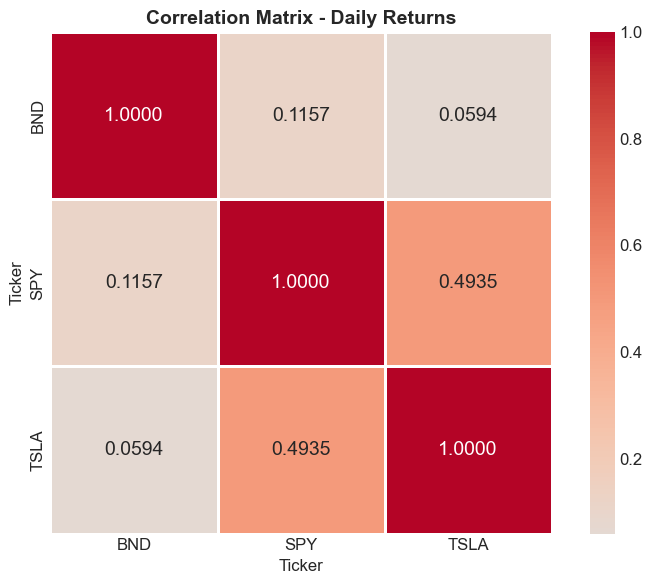

Done!


In [10]:

print("=== RISK METRICS ===\n")

# Annualization factor
trading_days = 252

for ticker in ['TSLA', 'SPY', 'BND']:
    returns = daily_returns[ticker]
    
    # Annualized return
    ann_return = returns.mean() * trading_days
    
    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(trading_days)
    
    # Sharpe Ratio (assuming risk-free rate of 2%)
    risk_free = 0.02
    sharpe = (ann_return - risk_free) / ann_vol
    
    # Value at Risk (95% confidence)
    var_95 = np.percentile(returns, 5)
    
    # Max Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    print(f"--- {ticker} ---")
    print(f"Annualized Return:    {ann_return:.2%}")
    print(f"Annualized Volatility:{ann_vol:.2%}")
    print(f"Sharpe Ratio:         {sharpe:.4f}")
    print(f"Value at Risk (95%):  {var_95:.2%}")
    print(f"Max Drawdown:         {max_drawdown:.2%}")
    print()

# Correlation matrix
print("=== CORRELATION MATRIX ===")
corr = daily_returns.corr()
print(corr.round(4))

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            center=0, square=True, linewidths=1,
            annot_kws={'size': 14})
plt.title('Correlation Matrix - Daily Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Done!")

EDA SUMMARY - KEY INSIGHTS"


1. DATA OVERVIEW
   - 2,888 trading days from Jan 2015 to Jun 2026
   - No missing values found across all 3 assets
   - TSLA grew from ~$14 to ~$411 (2,800%+ total return)
   - SPY grew from ~$169 to ~$741 (338% total return)
   - BND remained stable between $59-$75

2. VOLATILITY ANALYSIS
   - TSLA is the most volatile (57.18% annualized)
   - SPY has moderate volatility (17.65% annualized)
   - BND is the most stable (5.31% annualized)

3. RISK-ADJUSTED RETURNS (Sharpe Ratio)
   - TSLA: 0.7595 (highest - best risk-adjusted return)
   - SPY:  0.7042 (close second)
   - BND:  -0.0008 (essentially zero real return after inflation)

4. VALUE AT RISK (95% confidence, daily)
   - TSLA: -5.17% (on bad days, expect to lose up to 5.17%)
   - SPY:  -1.67%
   - BND:  -0.48%

5. STATIONARITY
   - Closing prices: NON-STATIONARY for all 3 assets
   - Daily returns: STATIONARY for all 3 assets
   - Implication: ARIMA must use d=1 (differencing)
     to make price series stationary before modeling

6. CORRELATIONS
   - TSLA & SPY: 0.4935 (moderate positive)
   - BND & SPY:  0.1157 (low positive - good diversifier)
   - BND & TSLA: 0.0594 (very low - excellent diversifier)
   - BND provides the best diversification benefit